In [1]:
import os, sys
import pickle

import numpy as np
import scipy
import pandas as pd
from scipy.stats import pearsonr, zscore
from scipy.ndimage import convolve1d
import statsmodels

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import r2_score

import imageio.v2 as imageio
import torch
import torch.nn.functional as F
from torchvision import transforms

from transformers import CLIPVisionModelWithProjection, CLIPImageProcessor

from utils import align_channels_across_runs, compute_ncsnr_all_timepoints, reshape_electrode_data_by_stimuli, extract_images_with_n_repeats, ncsnr_figs
# from PSN.psn import psn

from mne.stats import permutation_cluster_1samp_test
from concurrent.futures import ThreadPoolExecutor

np.random.seed(42)

In [2]:
is_interactive = 'ipykernel_launcher' in sys.argv[0]

if is_interactive:
    print('running interactively')
    get_ipython().run_line_magic('load_ext', 'autoreload')
    get_ipython().run_line_magic('autoreload', '2')
    get_ipython().run_line_magic('matplotlib', 'inline')
else:
    print('running non-interactively')

running interactively


In [3]:
base_dir = '/home/ri99/ieeg'
ieeg_dir = f'{base_dir}/data/subjects/111'
csv_dir = f'{base_dir}/data/nsd_PTB'
img_dir = f'{base_dir}/data/nsd_ecog'

data_dir = f'{base_dir}/data/hfb'
output_dir = f'{base_dir}/outputs/hfb'
cache_dir = f'{base_dir}/.cache'

os.makedirs(cache_dir, exist_ok=True)
sub = 11
n_blocks = -1  # -1 = use all blocks
n_runs = 56

sampling_rate = 1024  # Hz
baseline_time = 0.2  # seconds of data per trial before stimulus onset
# subject 111 had 5600 images split into 4 distinct sessions over 2 days (day 1: runs 1-12 and 13-24; day 2: runs 25-36 and 37-56)

load_from_file = False
skip_plotting = False
smoothing = False

if smoothing:
    window_size = 25
    stride = 10
    smooth_suffix = f'_window{window_size}_stride{stride}'
else:
    smooth_suffix = ''

In [4]:
curric = pd.read_csv(f"{csv_dir}/curriculum_patient{sub}.csv")
curric.head()

,Unnamed: 0,filename,inventory,coco_id,is_repeat,repetition_number,block
0,0,special_23715.png,1x-shared1000_A,23715.0,0,1,1
1,1,notspecial_24264.png,1x-shared1000_A,24264.0,0,1,1
2,2,pair_45_w_pagoda1.png,MST,NaN,0,1,1
3,3,pair_33_nsd_777_1_cocoid_68844.png,MST,68844.0,0,1,1
4,4,notspecial_36682.png,3x-shared1000_A,36682.0,0,1,1


In [5]:
if n_blocks == -1:  # use all available blocks
    block_list = curric['block'].unique().astype(str)
else:  # use n_blocks to specify instead
    block_list = [str(x) for x in range(1, n_blocks+1)]

print(block_list)
image_names = list(curric[curric['block'].isin(block_list)]['filename'])
print(len(image_names))

['1' '2' '3' '4' 'filler_block_1' 'filler_block_2']
5600


In [6]:
# load bipolar-referenced voltage trace data (no frequency decomposition) at 1024Hz
run_list = list(range(1, n_runs+1))

all_data = []
all_labels = []
time_ref = None

for run in tqdm(run_list):
    if load_from_file is False:
        data = np.load(f"{ieeg_dir}/bandpower1024/npy/sub1{sub}_NSD_run{run}_bandpower70-170.npy")
    labels = pd.read_csv(f"{ieeg_dir}/bandpower1024/ch_labels/sub1{sub}_NSD_run{run}_bandpower_channels.csv")
    time = np.load(f"{ieeg_dir}/bandpower1024/time/sub1{sub}_NSD_run{run}_bandpower_time.npy")

    if load_from_file is False:
        assert time.shape[0] == data.shape[2], f"time mismatch in run {run}"
        assert labels.shape[0] == data.shape[1], f"label mismatch in run {run}"
    
    if time_ref is None:
        time_ref = time
    else:
        assert np.allclose(time, time_ref), f"time array differs in run {run}"

    if load_from_file is False:
        all_data.append(data)
    all_labels.append(labels)

if load_from_file is False:
    print(len(all_data))
    del data

# delete to prevent using the wrong ones later; we use channel_info to index channel labels from here on
del labels

100%|██████████| 56/56 [00:11<00:00,  4.78it/s]

56


In [7]:
if load_from_file is False:
    # combine data across runs while dealing with some runs not having data from the same channels
    data, channel_info = align_channels_across_runs(all_data, all_labels)
    data = data.transpose(1,2,0).astype(np.float32)  # convert to channels x time x trials
    print(f"Final shape: {data.shape}")
    print(channel_info.head())
    channel_info.to_csv(f'{data_dir}/channel_info.csv', index=False)
else:
    channel_info = pd.read_csv(f'{data_dir}/channel_info.csv')

del all_labels

Aligning runs: 100%|██████████| 56/56 [00:07<00:00,  7.93it/s]



Channels with missing data (not present in all runs): ['LAP-pC_2-1', 'LmF-aI_6-5', 'LmF-aI_7-6', 'LsT-HC_2-1', 'LsT-HC_3-2', 'LsT-HC_5-4', 'LsT-HC_6-5', 'LsT-HC_8-7', 'LsT-Pu_6-5', 'LsT-Pu_7-6', 'LsT-Pu_8-7', 'RSP-pC_11-10', 'RSP-pC_12-11', 'RSP-pC_5-4', 'RSP-pC_6-5', 'RSP-pC_8-7', 'RSP-pC_9-8', 'RmF-aI_10-9', 'RmF-aI_11-10', 'RmF-aI_12-11', 'RmF-aI_6-5', 'RmF-oF_5-4', 'RmF-oF_8-7']
Inserted NaNs for missing data.
Final shape: (130, 2049, 5600)
   channel_name  channel_idx
0   LAP-pC_10-9            8
1  LAP-pC_11-10            9
2  LAP-pC_12-11           10
3    LAP-pC_2-1            0
4    LAP-pC_3-2            1


# reshape to identify repeated stimuli

In [8]:
if load_from_file is False:
    # First, reshape your electrode data using the existing function
    reshaped_electrode_data, stim_info = reshape_electrode_data_by_stimuli(
        data,  # Your electrode data (channels, time, trials)
        curric,         # Your events dataframe
        stim_column='coco_id'
    )

    if smoothing:  # sliding window smooth the data
        smoothing_kernel = np.ones(window_size) / stride
        
        plt.plot(reshaped_electrode_data[0, 0, :, :2])
        plt.title('unsmoothed data, channel 0, image 0, repeats 0-1')
        plt.show()
        reshaped_electrode_data = convolve1d(reshaped_electrode_data, smoothing_kernel, axis=2)
        plt.plot(reshaped_electrode_data[0, 0, :, :2])
        plt.title('smoothed data, channel 0, image 0, repeats 0-1')
        plt.show()
                        
    np.save(f'{data_dir}/reshaped_electrode_data{smooth_suffix}', reshaped_electrode_data)
    with open(f'{data_dir}/stim_info.pkl', 'wb') as f:
        pickle.dump(stim_info, f)

else:
    print('loading reshaped_electrode_data, stim_info from file')
    reshaped_electrode_data = np.load(f'{data_dir}/reshaped_electrode_data{smooth_suffix}.npy')
    with open(f'{data_dir}/stim_info.pkl', 'rb') as f:
        stim_info = pickle.load(f)
    print(reshaped_electrode_data.shape)

Original electrode data shape: (130, 2049, 5600)
Events dataframe shape: (5600, 7)
Number of unique stimuli: 2900
Maximum repetitions per stimulus: 4
Repetition distribution:
count
1     800
2    1600
3     400
4     100
Name: count, dtype: int64


100%|██████████| 2900/2900 [00:02<00:00, 1141.45it/s]


Final reshaped data shape: (130, 2900, 2049, 4)
Shape interpretation: (130 channels, 2900 images, 2049 timepoints, 4 max repeats)


# measure NCSNR and noise ceiling pct over time to identify electrodes with good signal 

Transposed data shape: (2900, 130, 4, 2049)
Shape interpretation: (2900 conditions/images, 130 channels, 4 trials/repeats, 2049 timepoints)
Computing NCSNR for 130 channels across 2049 timepoints...
Processing timepoint 1/2049 (0.0ms)


/gpfs/milgram/pi/turk-browne/projects/NSD_iEEG_share/scripts/utils.py:115: RuntimeWarning: Degrees of freedom <= 0 for slice.
  trial_var = np.nanvar(data_in, axis=2, ddof=1)
/gpfs/milgram/pi/turk-browne/projects/NSD_iEEG_share/scripts/utils.py:119: RuntimeWarning: Mean of empty slice
  data_var = np.nanvar(np.nanmean(data_in, axis=2), axis=1, ddof=1)
/gpfs/milgram/pi/turk-browne/projects/NSD_iEEG_share/scripts/utils.py:122: RuntimeWarning: divide by zero encountered in divide
  n_eff_inv = np.nanmean(np.where(n_per_cond > 0, 1.0 / n_per_cond, np.nan), axis=1)  # (channels,)


Processing timepoint 101/2049 (0.1ms)
Processing timepoint 201/2049 (0.2ms)
Processing timepoint 301/2049 (0.3ms)
Processing timepoint 401/2049 (0.4ms)
Processing timepoint 501/2049 (0.5ms)
Processing timepoint 601/2049 (0.6ms)
Processing timepoint 701/2049 (0.7ms)
Processing timepoint 801/2049 (0.8ms)
Processing timepoint 901/2049 (0.9ms)
Processing timepoint 1001/2049 (1.0ms)
Processing timepoint 1101/2049 (1.1ms)
Processing timepoint 1201/2049 (1.2ms)
Processing timepoint 1301/2049 (1.3ms)
Processing timepoint 1401/2049 (1.4ms)
Processing timepoint 1501/2049 (1.5ms)
Processing timepoint 1601/2049 (1.6ms)
Processing timepoint 1701/2049 (1.7ms)
Processing timepoint 1801/2049 (1.8ms)
Processing timepoint 1901/2049 (1.9ms)
Processing timepoint 2001/2049 (2.0ms)
NCSNR computation complete!
NCSNR results shape: (100, 2049)
NC results shape: (100, 2049)


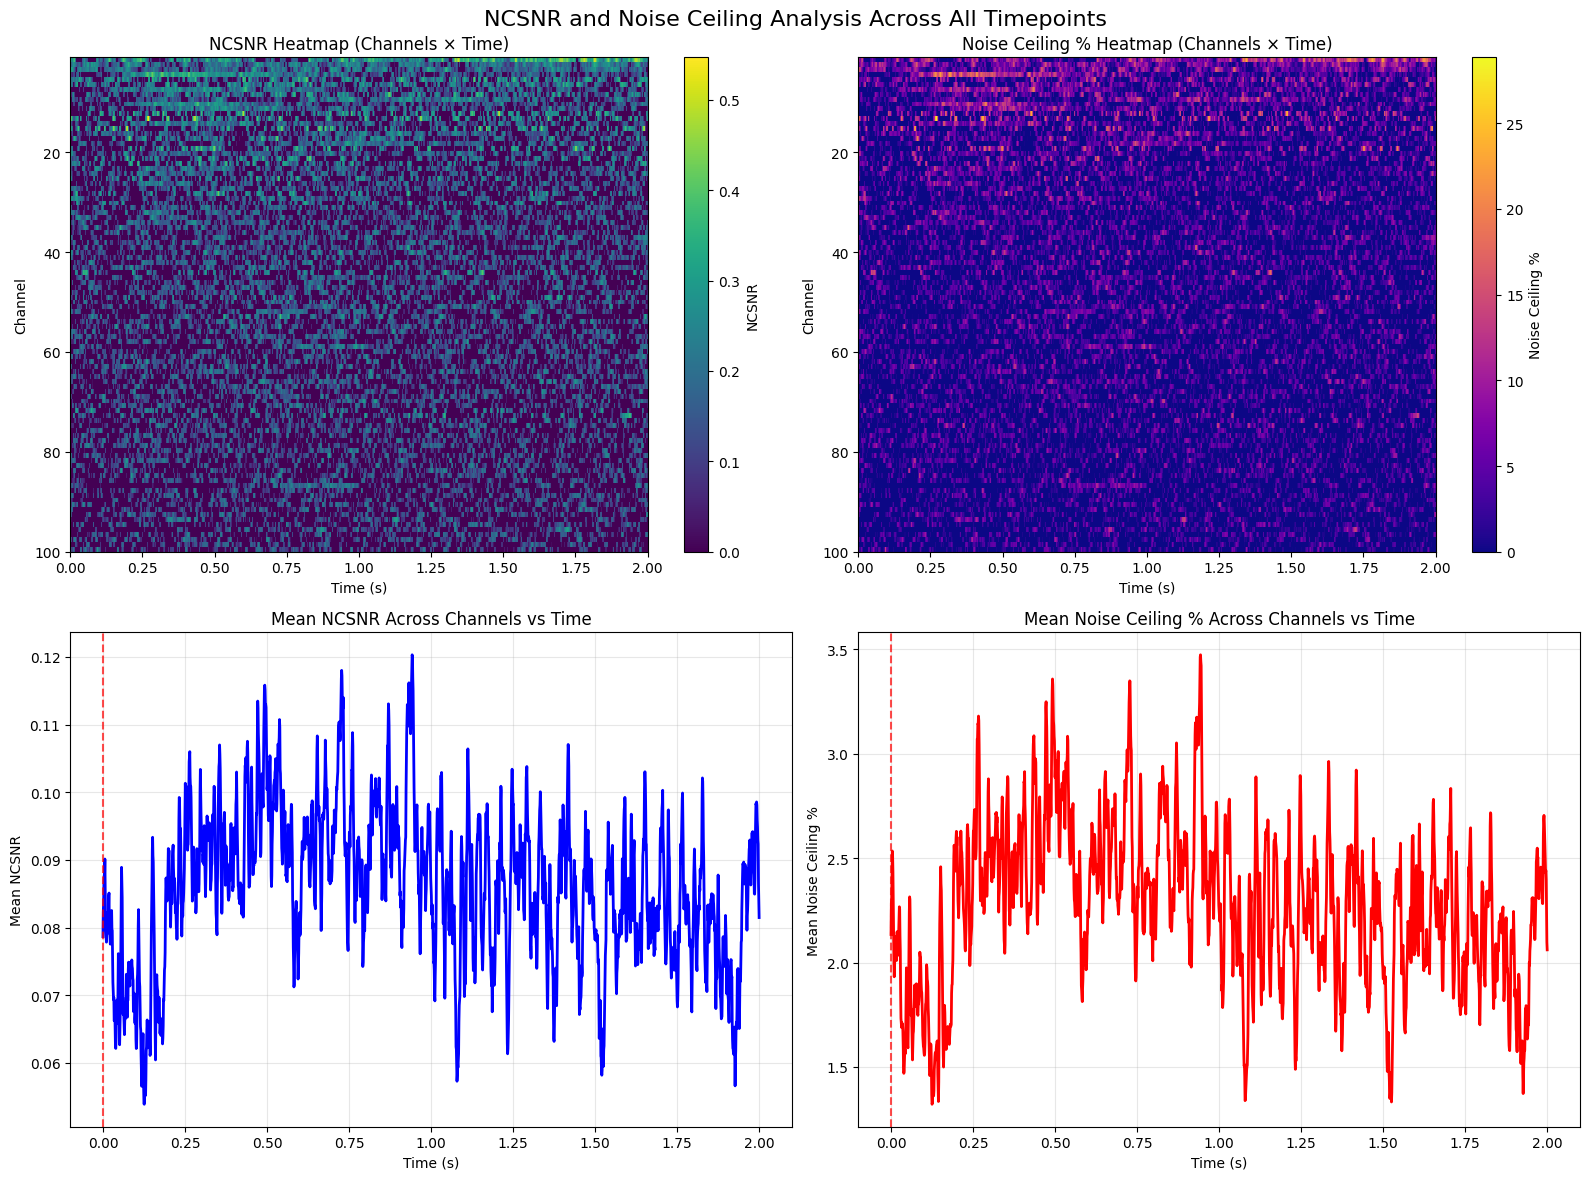


Summary Statistics:
Mean NCSNR across all channels and time: 0.086
Max NCSNR: 0.547
Mean Noise Ceiling across all channels and time: 2.3%
Max Noise Ceiling: 28.8%
Peak NCSNR time: 0.9ms
Peak NC time: 0.9ms


In [9]:
if load_from_file is False:
    data_slim = reshaped_electrode_data.transpose(1, 0, 3, 2)
    print(f"Transposed data shape: {data_slim.shape}")
    print(f"Shape interpretation: ({data_slim.shape[0]} conditions/images, {data_slim.shape[1]} channels, {data_slim.shape[2]} trials/repeats, {data_slim.shape[3]} timepoints)")
    np.save(f'{data_dir}/data_slim{smooth_suffix}', data_slim, allow_pickle=True)
    
    # Compute NCSNR for all timepoints
    ncsnr_all, nc_all = compute_ncsnr_all_timepoints(data_slim, time)
    np.save(f'{data_dir}/ncsnr_all{smooth_suffix}', ncsnr_all, allow_pickle=True)
    np.save(f'{data_dir}/nc_all{smooth_suffix}', nc_all, allow_pickle=True)
else:
    print('loading processed data and ncsnr from file')
    data_slim = np.load(f'{data_dir}/data_slim{smooth_suffix}.npy')
    ncsnr_all = np.load(f'{data_dir}/ncsnr_all{smooth_suffix}.npy')
    nc_all = np.load(f'{data_dir}/nc_all{smooth_suffix}.npy')
    
rankings = np.flip(np.argsort(ncsnr_all.mean(1)))
# Visualize the results
if not skip_plotting:
    ncsnr_figs(ncsnr_all[rankings[:100]], nc_all[rankings[:100]], time, save_path=f'{output_dir}/ncsnr_bandpower{smooth_suffix}')
channel_info.iloc[rankings].to_csv(f'{output_dir}/ncsnr_rankings_desc{smooth_suffix}')

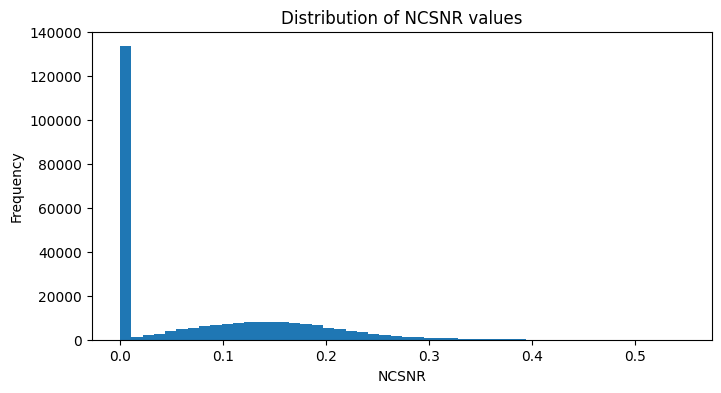

In [10]:
if not skip_plotting:
    plt.figure(figsize=(8, 4))
    plt.hist(ncsnr_all.flatten(), bins=50)
    plt.title("Distribution of NCSNR values")
    plt.xlabel("NCSNR")
    plt.ylabel("Frequency")
    plt.show()

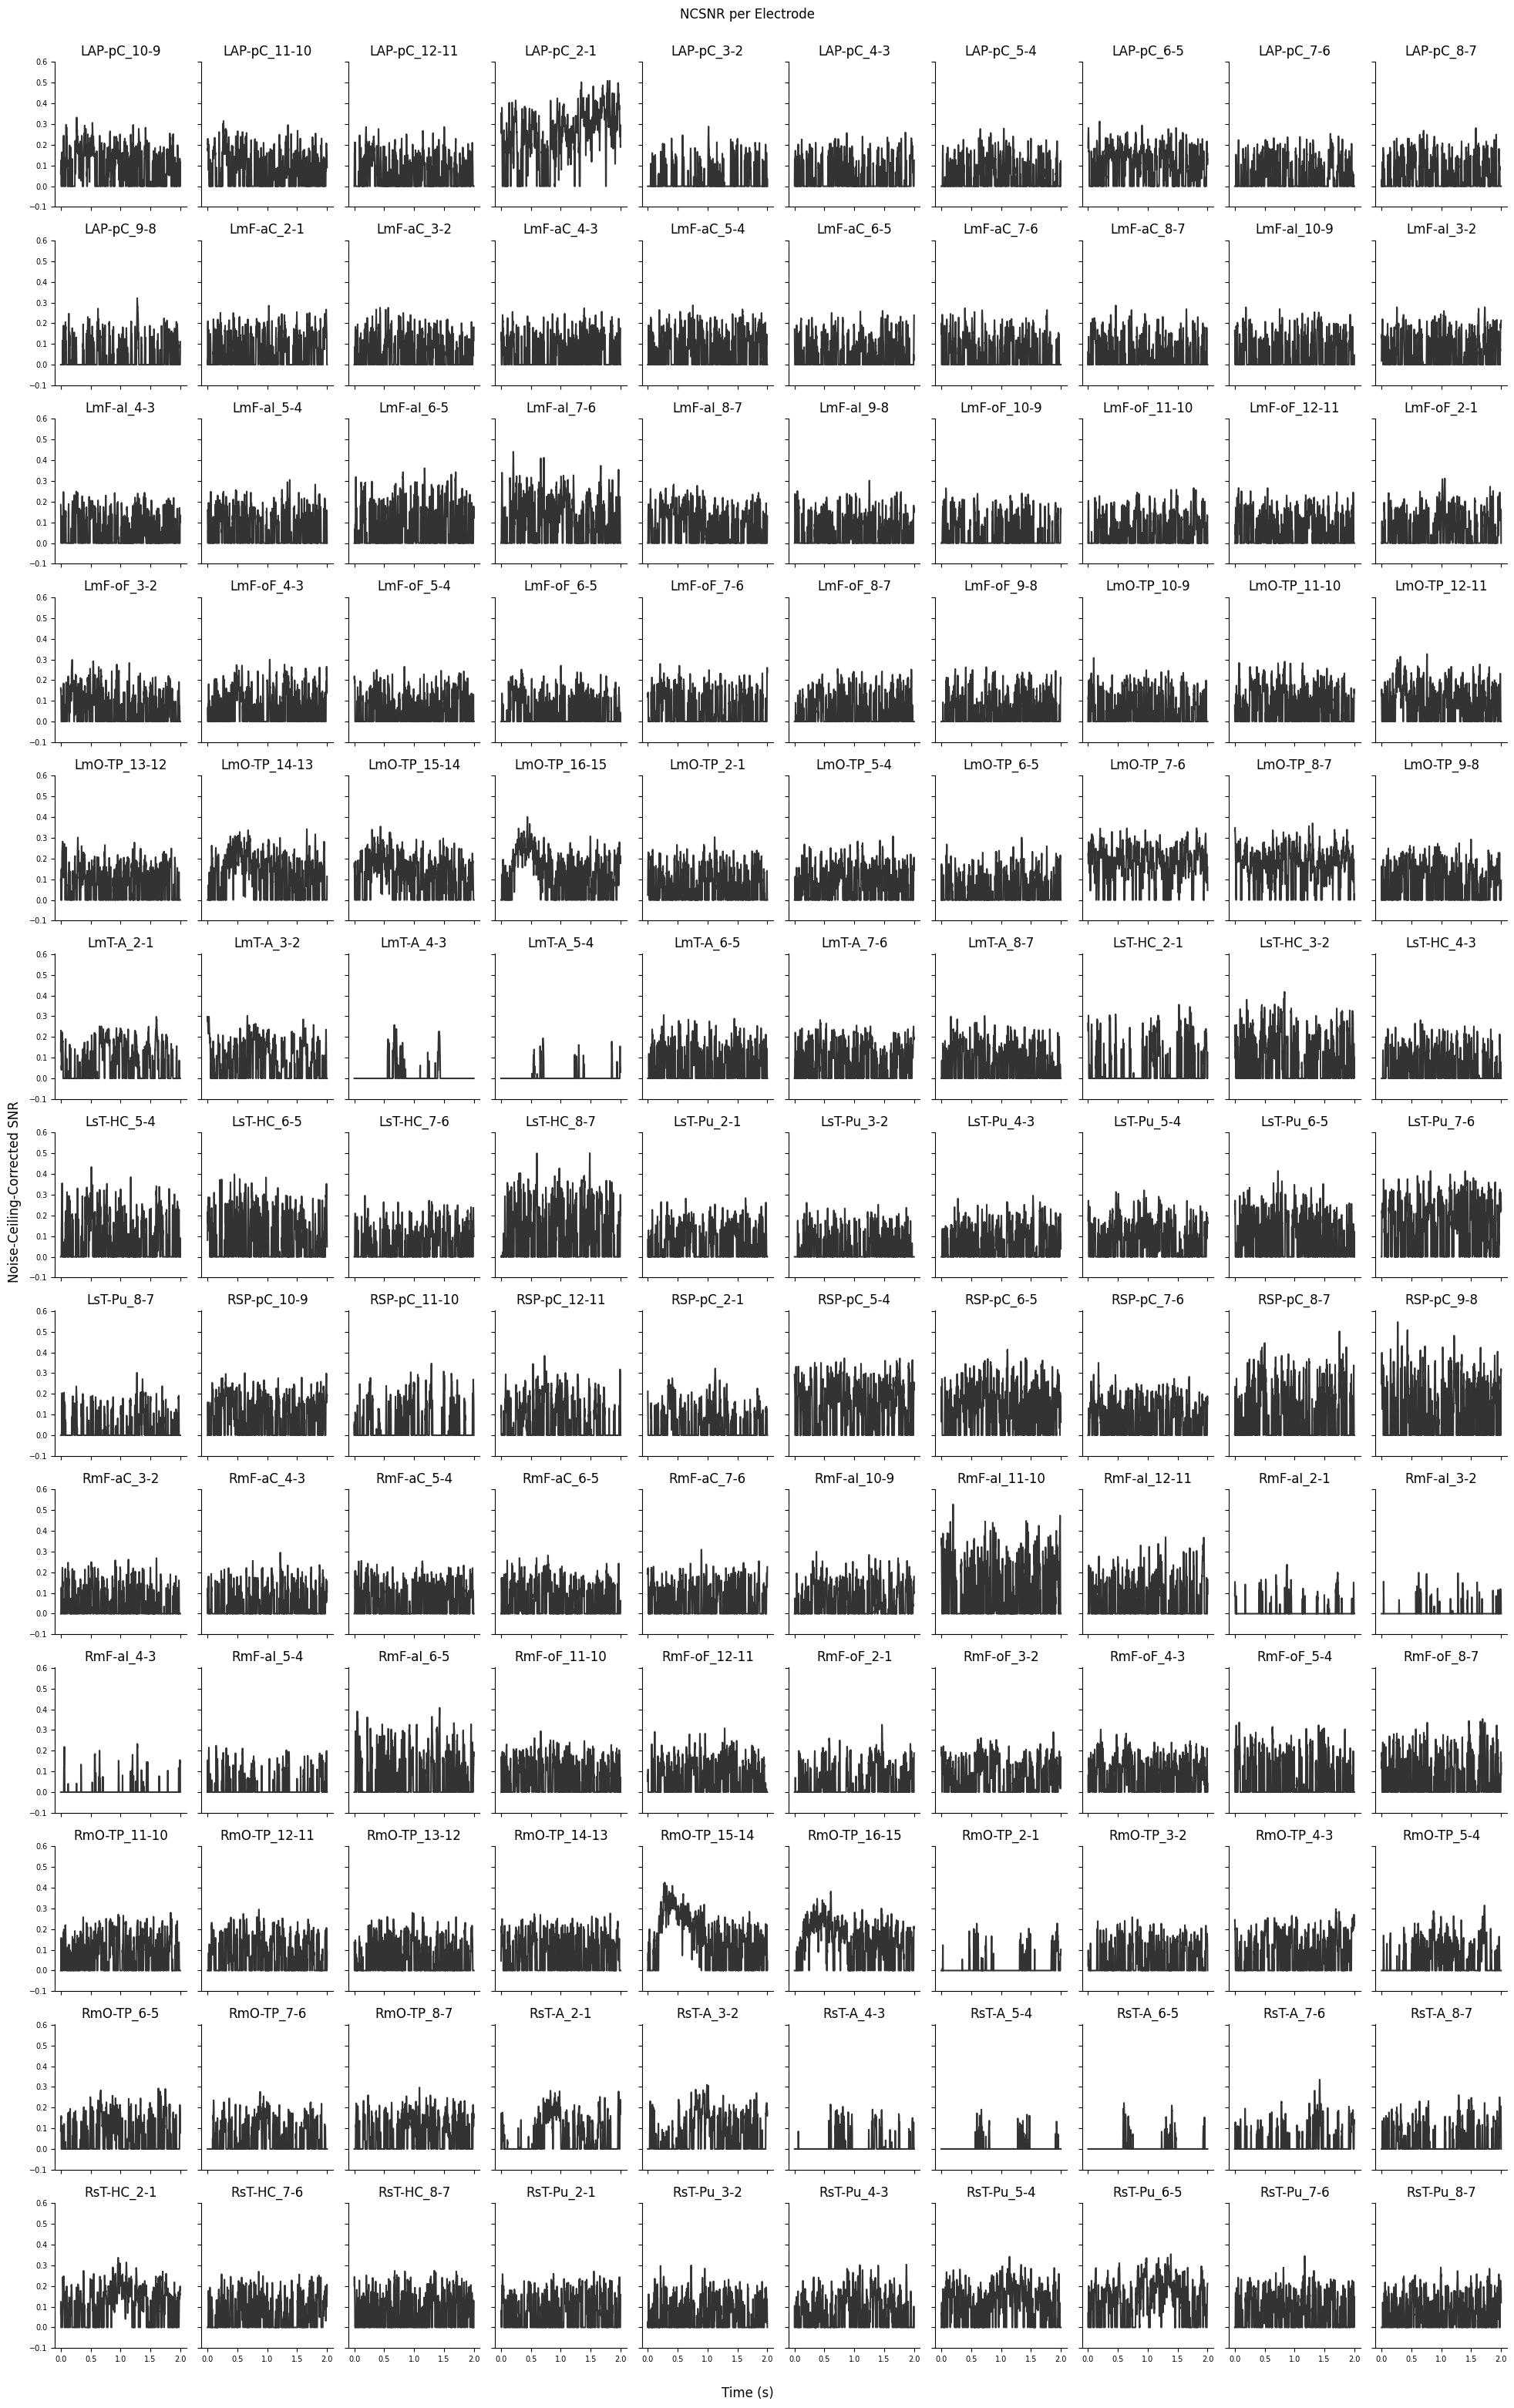

In [11]:
n_ch = ncsnr_all.shape[0]

if not skip_plotting:
    n_cols = 10
    n_rows = int(np.ceil(n_ch / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 32), sharex=True, sharey=True)
    fig.suptitle(f'NCSNR per Electrode')
    fig.supxlabel('Time (s)')
    fig.supylabel('Noise-Ceiling-Corrected SNR')
    axes = axes.flatten()
    
    for ch in range(n_ch):
        ax = axes[ch]
        ax.plot(time, ncsnr_all[ch], color='k', alpha=0.8)
        ax.set_title(channel_info.iloc[ch]["channel_name"])
        ax.tick_params(labelsize=7)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    for ch in range(n_ch, len(axes)):
        axes[ch].axis('off')
    
    ymin = np.nanmin(ncsnr_all)
    ymax = np.nanmax(ncsnr_all)
    ypad = (ymax - ymin) * 0.1
    axes[0].set_ylim(-0.1, ymax + ypad)
    
    plt.tight_layout(rect=[0.01, 0.01, 1, 0.98])
    if not load_from_file:
        plt.savefig(f'{output_dir}/ncsnr_per_channel{smooth_suffix}')
    plt.show()

In [12]:
# perm_path = f"{output_dir}/ncsnr_perm"
# os.makedirs(f"{perm_path}", exist_ok=True)
# n_perms = 1024

# if is_interactive:
#     perm_start, perm_end = 0, 2
# else:
#     task_id    = int(sys.argv[1])
#     batch_size = int(sys.argv[2])
#     perm_start = task_id * batch_size
#     perm_end   = min(perm_start + batch_size, n_perms)

# if not is_interactive:
#     for perm_id in range(perm_start, perm_end):
#         path = f"{perm_path}/perm_{perm_id:04d}.npy"
#         if os.path.exists(path):
#             print(f"Perm {perm_id}: loaded from disk")
#             continue
    
#         rng = np.random.default_rng(perm_id)
#         data_shuffled = data_slim.copy()
#         for img in range(data_slim.shape[0]):
#             perm = rng.permutation(data_slim.shape[2])
#             data_shuffled[img] = np.take(data_slim[img], perm, axis=1)
    
#         ncsnr_perm, _ = compute_ncsnr_all_timepoints(data_shuffled, time)
#         if not load_from_file:

#             np.save(path, ncsnr_perm)
#         print(f"Perm {perm_id}: computed and saved")

In [13]:
# if not is_interactive:
#     null_mean = null_ncsnr.mean(axis=0)   # (n_channels, n_timepoints)
#     null_std  = null_ncsnr.std(axis=0)
    
#     # Observed z-scores
#     z_obs = (ncsnr_all - null_mean) / null_std  # (n_channels, n_timepoints)
    
#     threshold = 1.645  # p=0.05 one-sided
    
#     def find_clusters(z, threshold):
#         """Returns list of (indices, mass) for suprathreshold clusters."""
#         sig = z > threshold
#         clusters = []
#         in_cluster = False
#         for t in range(len(z)):
#             if sig[t] and not in_cluster:
#                 start = t
#                 in_cluster = True
#             elif not sig[t] and in_cluster:
#                 idx = np.arange(start, t)
#                 clusters.append((idx, z[idx].sum()))
#                 in_cluster = False
#         if in_cluster:
#             idx = np.arange(start, len(z))
#             clusters.append((idx, z[idx].sum()))
#         return clusters
    
#     # Null distribution of max cluster mass, per channel
#     null_max_mass = np.zeros((len(null_ncsnr), n_ch))  # (n_perms, n_channels)
#     for i, null_map in enumerate(null_ncsnr):
#         z_null = (null_map - null_mean) / null_std
#         for ch in range(n_ch):
#             clusters = find_clusters(z_null[ch], threshold)
#             null_max_mass[i, ch] = max((m for _, m in clusters), default=0)
    
#     # Cluster p-values per channel
#     cluster_results = []
#     for ch in range(n_ch):
#         clusters = find_clusters(z_obs[ch], threshold)
#         ch_results = []
#         for idx, mass in clusters:
#             pval = (null_max_mass[:, ch] >= mass).mean()
#             ch_results.append((idx, mass, pval))
#         cluster_results.append(ch_results)

In [14]:
# n_cols = 10
# n_rows = int(np.ceil(n_ch / n_cols))
# fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 32), sharex=True, sharey=True)
# fig.suptitle(f'NCSNR per Electrode (Cluster Permutation Test, p<0.05)')
# fig.supxlabel('Time (s)')
# fig.supylabel('Noise-Ceiling-Corrected SNR')
# axes = axes.flatten()

# for ch in range(n_ch):
#     ax = axes[ch]
#     ax.plot(time, ncsnr_all[ch], color='k')
#     ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

#     for idx, mass, pval in cluster_results[ch]:
#         if pval < 0.05:
#             ax.axvspan(time[idx[0]], time[idx[-1]], alpha=0.3, color='red')

#     ax.set_title(channel_info.iloc[ch]["channel_name"])
#     ax.tick_params(labelsize=7)
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)

# for ch in range(n_ch, len(axes)):
#     axes[ch].axis('off')

# ymin = np.nanmin(ncsnr_all)
# ymax = np.nanmax(ncsnr_all)
# ypad = (ymax - ymin) * 0.1
# axes[0].set_ylim(ymin - ypad, ymax + ypad)

# plt.tight_layout(rect=[0.01, 0.01, 1, 0.98])
# if not load_from_file:
#     plt.savefig(f'{output_dir}/significant_ncsnr')
# plt.show()

In [15]:
# calculate average response of each channel
print(reshaped_electrode_data.shape)

# baseline_start_idx = int(np.floor(baseline_time+0.2 * sampling_rate))  # baseline duration (sec; -0.2-0.2sec post stim onset) * sampling rate (1/sec)
# baseline_mean = np.mean(reshaped_electrode_data[:,:,:baseline_start_idx,:], axis=2)
# avg_signal = reshaped_electrode_data - baseline_mean[:,:,np.newaxis,:]  # baseline subtract per trial

avg_signal = np.nanmean(reshaped_electrode_data, axis=(3,1))  # average over repeats (dim 3) and conditions (dim 1)

print(avg_signal.shape)

(130, 2900, 2049, 4)
(130, 2049)


Plotting...


100%|██████████| 130/130 [00:08<00:00, 14.46it/s]


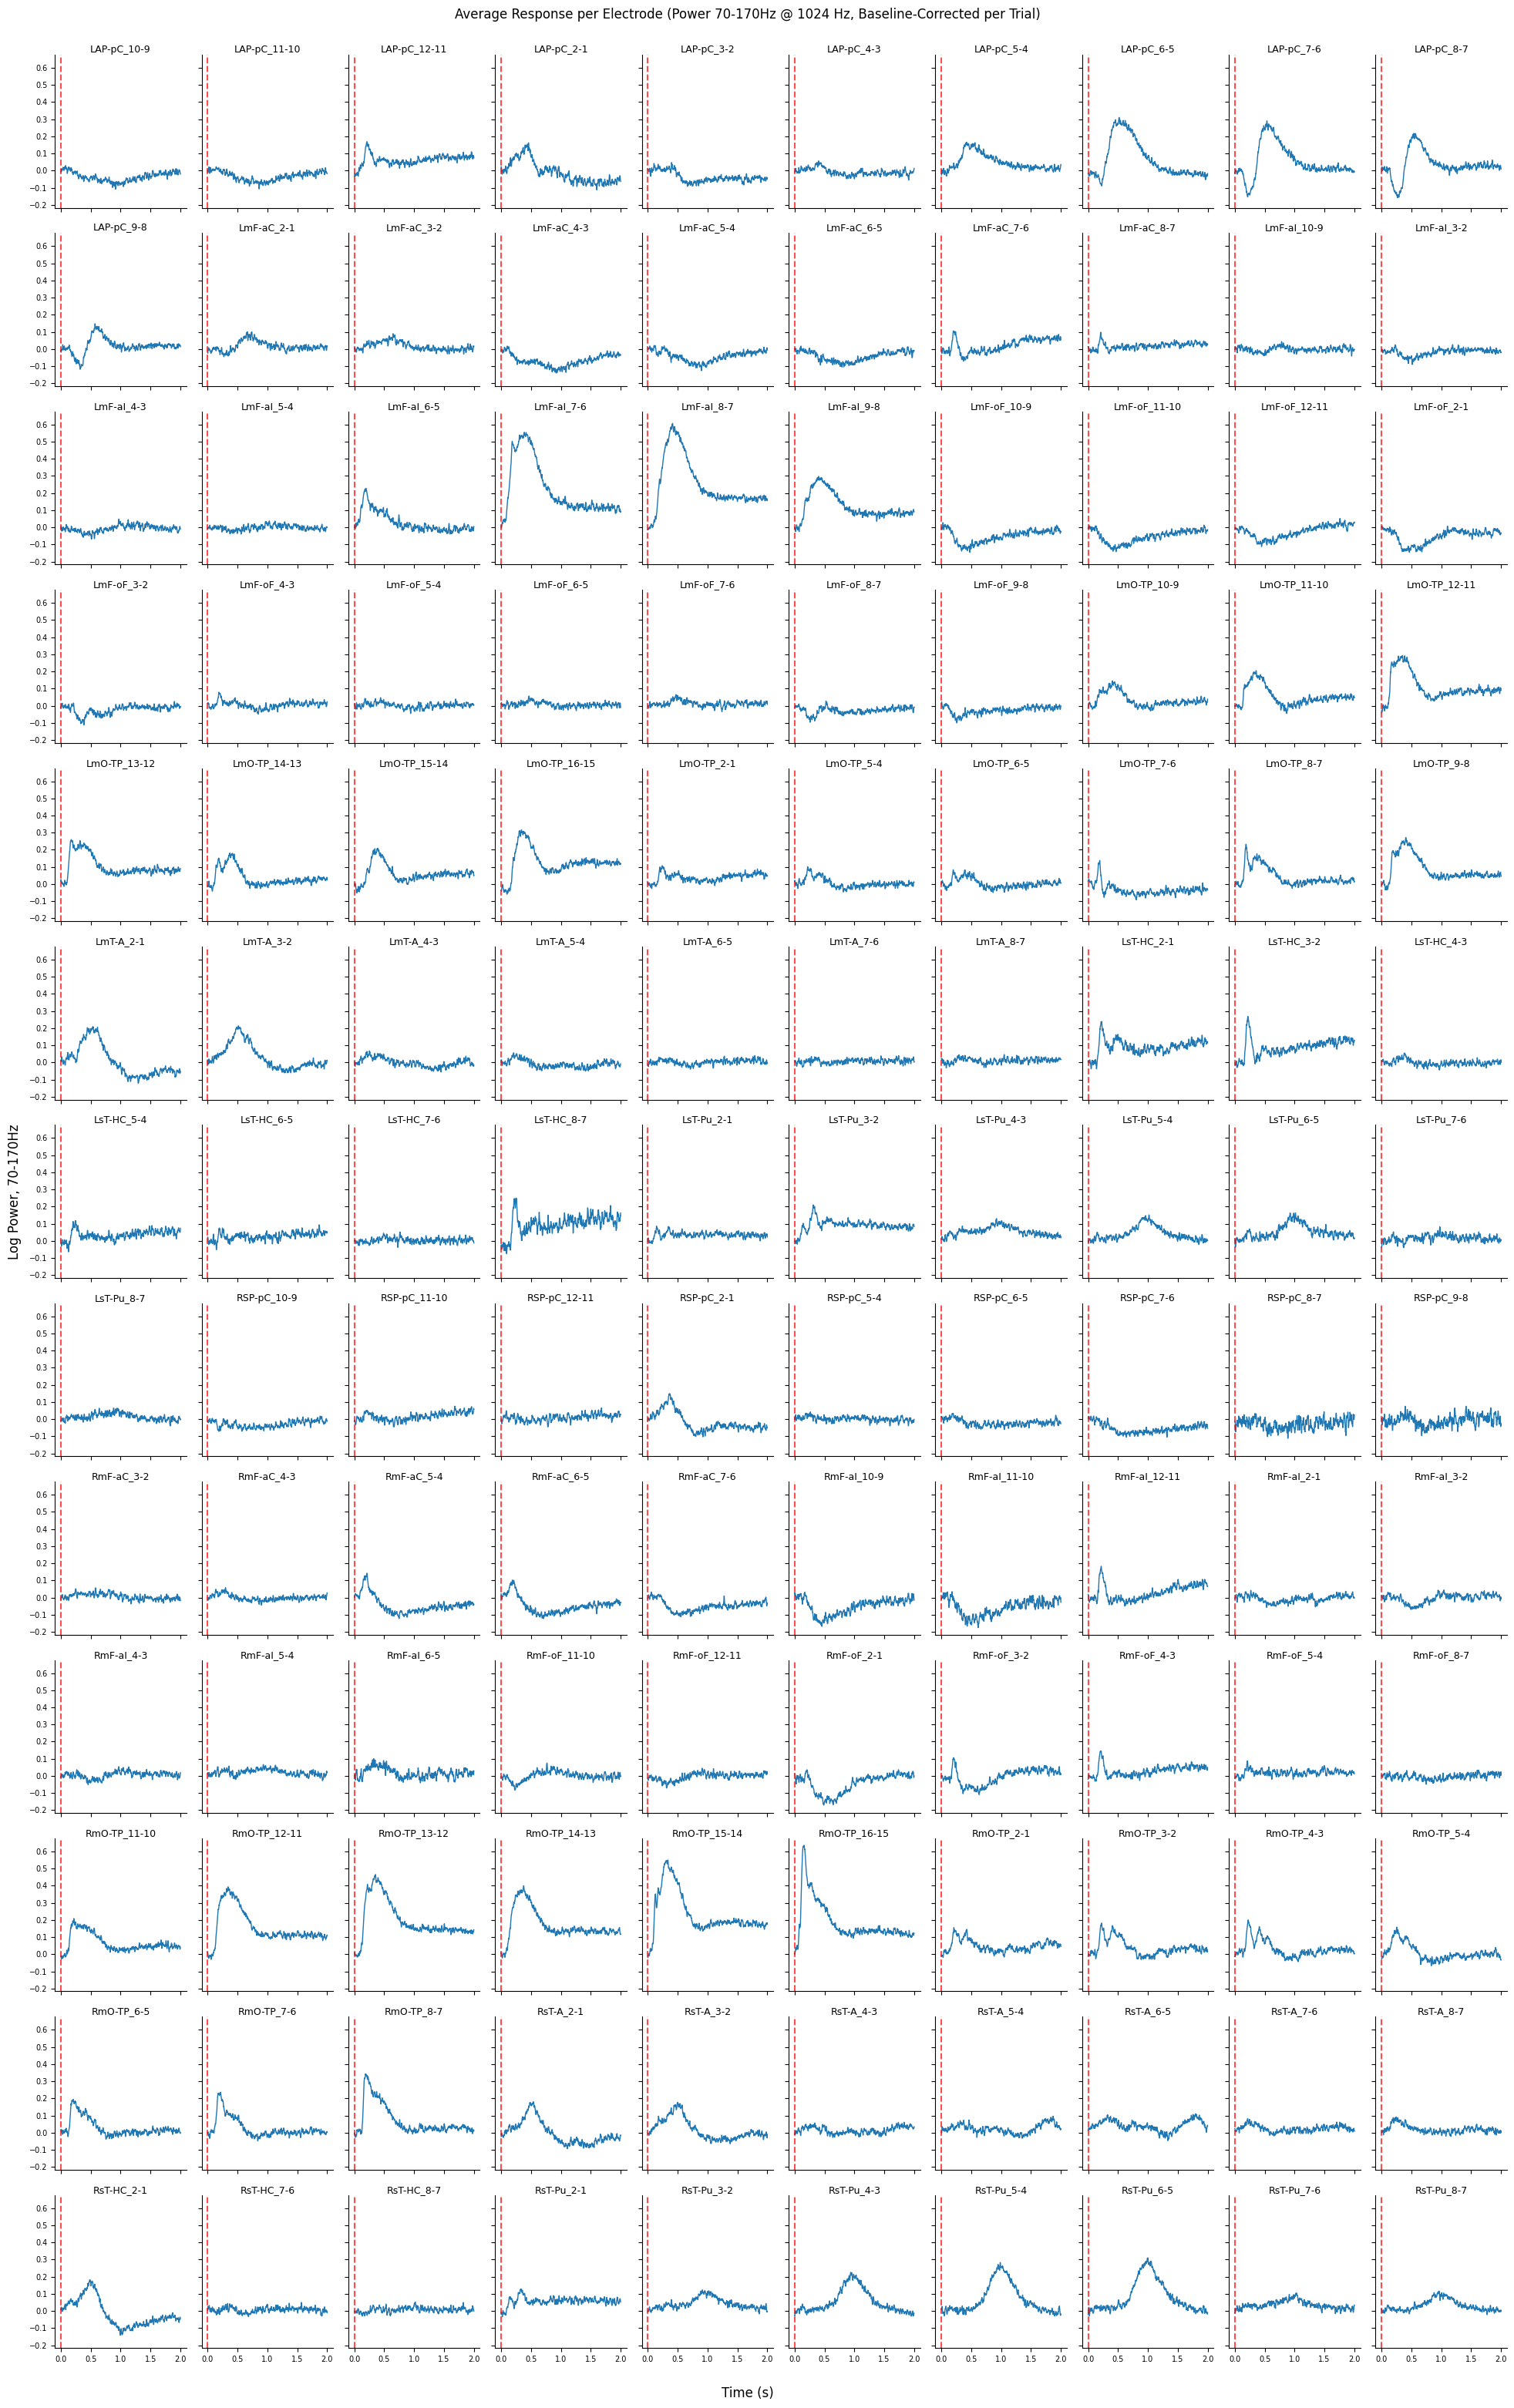

In [16]:
if not skip_plotting:
    ncols = 10
    nrows = int(np.ceil(len(avg_signal) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 32), sharex=True, sharey=True)
    fig.suptitle(f'Average Response per Electrode (Power 70-170Hz @ {sampling_rate} Hz, Baseline-Corrected per Trial)')
    fig.supxlabel('Time (s)')
    fig.supylabel('Log Power, 70-170Hz')
    axes_flat = axes.flatten()
    
    print('Plotting...')
    for i in tqdm(range(len(avg_signal))):
        ax = axes_flat[i]
        ax.plot((np.arange(avg_signal.shape[1])/sampling_rate), avg_signal[i], linewidth=1)
        ax.axvline(x=0, color='red', linestyle='--', alpha=0.7)
        
        curr_label = channel_info.iloc[i]
        ax.set_title(f"{curr_label['channel_name']}", fontsize=9, pad=2)
        
        ax.tick_params(labelsize=7)
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    plt.tight_layout(rect=[0.01, 0.01, 1, 0.98])
    if not load_from_file:
        plt.savefig(f'{output_dir}/avg_response_bandpower{smooth_suffix}')
    plt.show()

In [17]:
print(avg_signal.shape)
print(reshaped_electrode_data.shape)

(130, 2049)
(130, 2900, 2049, 4)


In [18]:
# X = np.nanmean(reshaped_electrode_data, axis=3).transpose(1, 2, 0)
# X = np.nan_to_num(X, nan=0.0)
# t_obs, clusters, cluster_pv, H0 = permutation_cluster_1samp_test(X, n_jobs=-1)

In [19]:
# sig_indices = np.where(cluster_pv < 0.05)[0]

# print(f"Found {len(sig_indices)} significant clusters!")

# significant_points = np.zeros(f_obs.shape, dtype=bool)

# for i in sig_indices:
#     significant_points[clusters[i]] = True

# channels_with_sig = np.any(significant_points, axis=0)
# print(f"Channels with significant clusters: {np.where(channels_with_sig)[0]}")

# plt.figure(figsize=(10, 6))
# plt.imshow(t_obs.T, aspect='auto', origin='lower', cmap='RdBu_r')
# plt.colorbar(label='Statistic Value')

# plt.contour(significant_points.T, colors='black', levels=[0.5], linestyles='--')

# plt.xlabel('Timepoints')
# plt.ylabel('Channels')
# plt.title('Significant Clusters (p < 0.05)')
# plt.show()

In [20]:
# def save_result(ch, t_obs, clusters, cluster_pv, H0, save_path):
#     np.save(save_path,
#             {"t_obs": t_obs, "clusters": clusters, "cluster_pv": cluster_pv, "H0": H0},
#             allow_pickle=True)

# print(reshaped_electrode_data.shape)
# ch_timeseries = np.nanmean(reshaped_electrode_data, axis=3)
# print(ch_timeseries.shape)

In [21]:
# perm_path = f"{output_dir}/cluster_perm"
# os.makedirs(perm_path, exist_ok=True)

# if is_interactive:  # Jupyter notebook
#     ch_start, ch_end = 0, n_ch
# else:  # SLURM
#     task_id    = int(sys.argv[1])
#     batch_size = int(sys.argv[2])
#     ch_start   = task_id * batch_size
#     ch_end     = min(ch_start + batch_size, n_ch)
    
# results = [None] * n_ch
# with ThreadPoolExecutor(max_workers=None) as executor:  # None = auto-compute number of available workers
#     for ch in range(ch_start, ch_end):
#         path = f"{perm_path}/ch_{ch:03d}.npy"
#         if os.path.exists(path):
#             d = np.load(path, allow_pickle=True).item()
#             results[ch] = (d["t_obs"], d["clusters"], d["cluster_pv"], d["H0"])
#             print(f"Channel {ch}: loaded from disk")
#         else:
#             t_obs, clusters, cluster_pv, H0 = permutation_cluster_1samp_test(
#                 ch_timeseries[ch],
#                 tail=0,           # two-sided
#                 n_permutations=1024,
#                 adjacency=None,   # linear timepoint adjacency
#                 seed=42,
#                 n_jobs=-1
#             )
#             results[ch] = (t_obs, clusters, cluster_pv, H0)
#             executor.submit(save_result, ch, t_obs, clusters, cluster_pv, H0, path)
#             print(f"Channel {ch}: computed and saving")

In [22]:
# n_cols = 10
# n_rows = int(np.ceil(n_ch / n_cols))
# fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 32), sharex=True, sharey=True)
# fig.suptitle(f'Average Response per Electrode (Power 70-170Hz @ {sampling_rate} Hz, Baseline-Corrected per Trial)')
# fig.supxlabel('Time (s)')
# fig.supylabel('Log Power, 70-170Hz (High Frequency Broadband)')
# axes = axes.flatten()

# for ch in range(n_ch):
#     ax = axes[ch]
#     # if results[ch] is None:
#     #     ax.axis('off')
#     #     continue

#     ts = ch_timeseries[ch]
#     # t_obs, clusters, cluster_pv, _ = results[ch]
#     mean = np.nanmean(ts, axis=0)
#     ci = 1.96 * np.nanstd(ts, axis=0) / np.sqrt(ts.shape[0])

#     ax.plot(time, mean, color='k')
#     ax.fill_between(time, mean - ci, mean + ci, alpha=0.3, color='k')
#     ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
#     # for cluster_idx, pval in zip(clusters, cluster_pv):
#     #     if pval < 0.05:
#     #         start, end = cluster_idx[0][0], cluster_idx[0][-1]
#     #         color = 'red' if t_obs[cluster_idx[0]].mean() > 0 else 'blue'
#     #         ax.axvspan(time[start], time[end], alpha=0.3, color=color)
#     ax.set_title(channel_info.iloc[ch]["channel_name"])
#     ax.tick_params(labelsize=7)
    
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)

# # hide unused axes
# for ch in range(n_ch, len(axes)):
#     axes[ch].axis('off')

# plt.tight_layout(rect=[0.01, 0.01, 1, 0.98])
# if not load_from_file:
#     plt.savefig(f'{output_dir}/significant_hfb')
# plt.show()

In [23]:
channel_info.iloc[rankings[:20]]

,channel_name,channel_idx
3,LAP-pC_2-1,0
47,LmO-TP_7-6,40
48,LmO-TP_8-7,41
104,RmO-TP_15-14,107
69,LsT-Pu_7-6,69
75,RSP-pC_5-4,72
105,RmO-TP_16-15,108
76,RSP-pC_6-5,73
127,RsT-Pu_6-5,123
43,LmO-TP_16-15,49


In [24]:
# def plot_top_k_electrodes(rankings, k=20, n_pairs_per_row=4):
#     top_k = rankings[:k]
#     n_cols = n_pairs_per_row * 2
#     n_rows = int(np.ceil(k / n_pairs_per_row))
    
#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.2, n_rows * 2.8))
#     fig.suptitle(f'Top-{k} Electrodes by NCSNR: HFB (left) & NCSNR (right)', fontsize=13)
#     axes = axes.flatten()
    
#     # Compute y-limits for each modality across all top-k channels
#     hfb_min, hfb_max = np.inf, -np.inf
#     ncsnr_min, ncsnr_max = np.inf, -np.inf
    
#     for ch in top_k:
#         ts = ch_timeseries[ch]
#         mean = np.nanmean(ts, axis=0)
#         ci = 1.96 * np.nanstd(ts, axis=0) / np.sqrt(ts.shape[0])
#         hfb_min = min(hfb_min, np.nanmin(mean - ci))
#         hfb_max = max(hfb_max, np.nanmax(mean + ci))
#         ncsnr_min = min(ncsnr_min, np.nanmin(ncsnr_all[ch]))
#         ncsnr_max = max(ncsnr_max, np.nanmax(ncsnr_all[ch]))
    
#     hfb_pad = (hfb_max - hfb_min) * 0.1
#     ncsnr_pad = (ncsnr_max - ncsnr_min) * 0.1
    
#     for rank, ch in enumerate(top_k):
#         col_pair = rank % n_pairs_per_row
#         row = rank // n_pairs_per_row
#         ax_hfb = axes[row * n_cols + col_pair * 2]
#         ax_ncsnr = axes[row * n_cols + col_pair * 2 + 1]
#         ch_name = channel_info.iloc[ch]["channel_name"]
        
#         ts = ch_timeseries[ch]
#         mean = np.nanmean(ts, axis=0)
#         ci = 1.96 * np.nanstd(ts, axis=0) / np.sqrt(ts.shape[0])
#         ax_hfb.plot(time, mean, color='k')
#         ax_hfb.fill_between(time, mean - ci, mean + ci, alpha=0.3, color='k')
#         ax_hfb.axhline(0, color='gray', linestyle='--', linewidth=0.8)
#         ax_hfb.set_ylim(hfb_min - hfb_pad, hfb_max + hfb_pad)
#         ax_hfb.set_title(f'#{rank+1} {ch_name}\nHFB', fontsize=7)
        
#         ax_ncsnr.plot(time, ncsnr_all[ch], color='steelblue', alpha=0.8)
#         ax_ncsnr.axhline(0, color='gray', linestyle='--', linewidth=0.8)
#         ax_ncsnr.set_ylim(ncsnr_min - ncsnr_pad, ncsnr_max + ncsnr_pad)
#         ax_ncsnr.set_title(f'#{rank+1} {ch_name}\nNCSNR', fontsize=7)
        
#         for ax in (ax_hfb, ax_ncsnr):
#             ax.tick_params(labelsize=6)
#             ax.spines['top'].set_visible(False)
#             ax.spines['right'].set_visible(False)
    
#     used = k * 2
#     for i in range(used, len(axes)):
#         axes[i].axis('off')
#     plt.tight_layout(rect=[0, 0, 1, 0.97])
#     if not load_from_file:
#         plt.savefig(f'{output_dir}/top{k}_hfb_ncsnr')
#     plt.show()
    
# plot_top_k_electrodes(rankings, k=20)

In [25]:
reshaped_electrode_data.shape

(130, 2900, 2049, 4)

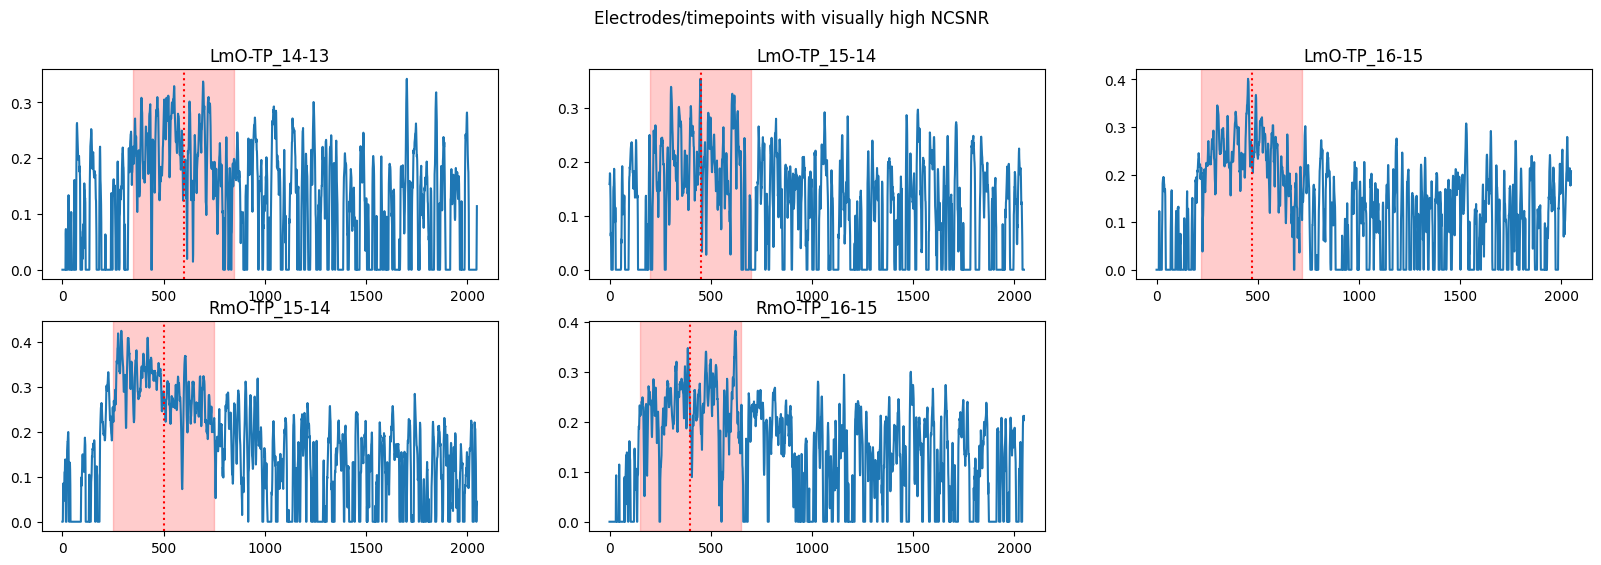

In [26]:
# as first pass, select electrodes with visually clear NCSNR curves above 0 for some time, select a constant amount of time per electrode
# 3, 41, 42, 43, 104, 105, 120, 127 (0-indexed)
high_ncsnr_idx = [41, 42, 43, 104, 105]
high_ncsnr_labels = [channel_info.iloc[i]["channel_name"] for i in high_ncsnr_idx]
window_centers = [600, 450, 470, 500, 400]
window = 500

rows = 2
cols = int(np.ceil(len(high_ncsnr_idx) / rows))
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 3))
fig.suptitle('Electrodes/timepoints with visually high NCSNR')
axes_flat = axes.flatten()
for i in range(len(high_ncsnr_idx)):
    ax = axes_flat[i]
    ax.plot(ncsnr_all[high_ncsnr_idx][i])
    ax.axvline(window_centers[i], color='red', linestyle=':')
    ax.axvspan(window_centers[i] - window/2, window_centers[i] + window/2,
               alpha=0.2, color='red')
    ax.set_title(high_ncsnr_labels[i])
# Hide unused axes
for j in range(len(high_ncsnr_idx), len(axes_flat)):
    axes_flat[j].set_visible(False)
plt.show()

In [27]:
print(reshaped_electrode_data.shape)
half = window // 2
subsets = [
    reshaped_electrode_data[idx, :, window_centers[i] - half : window_centers[i] + half, :]
    for i, idx in enumerate(high_ncsnr_idx)
]

reduced_data = np.stack(subsets)
print(reduced_data.shape)

(130, 2900, 2049, 4)
(5, 2900, 500, 4)


In [28]:
if load_from_file is False:
    np.save(f'{output_dir}/top_ncsnr_electrodes_timepoints{smooth_suffix}', reduced_data, allow_pickle=True)
    print('saved reduced data after feature selection')

saved reduced data after feature selection


In [29]:
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr

data = np.nanmean(reduced_data, axis=3)
print(data.shape)

# Per-channel RDMs (averaged over time, or at a specific t)
rdms_channels = []
for ch in range(len(data)):
    X = data[ch]  # (2900, 500)
    rdm = squareform(pdist(X, metric='correlation'))
    print(rdm.shape)
    rdms_channels.append(rdm[np.triu_indices(2900, k=1)])
    print(rdms_channels[-1].shape)

rdm = np.corrcoef(rdms_channels)  # 5x5 channel similarity
print(rdm.shape)

(5, 2900, 500)
(2900, 2900)
(4203550,)
(2900, 2900)
(4203550,)
(2900, 2900)
(4203550,)
(2900, 2900)
(4203550,)
(2900, 2900)
(4203550,)
(5, 5)


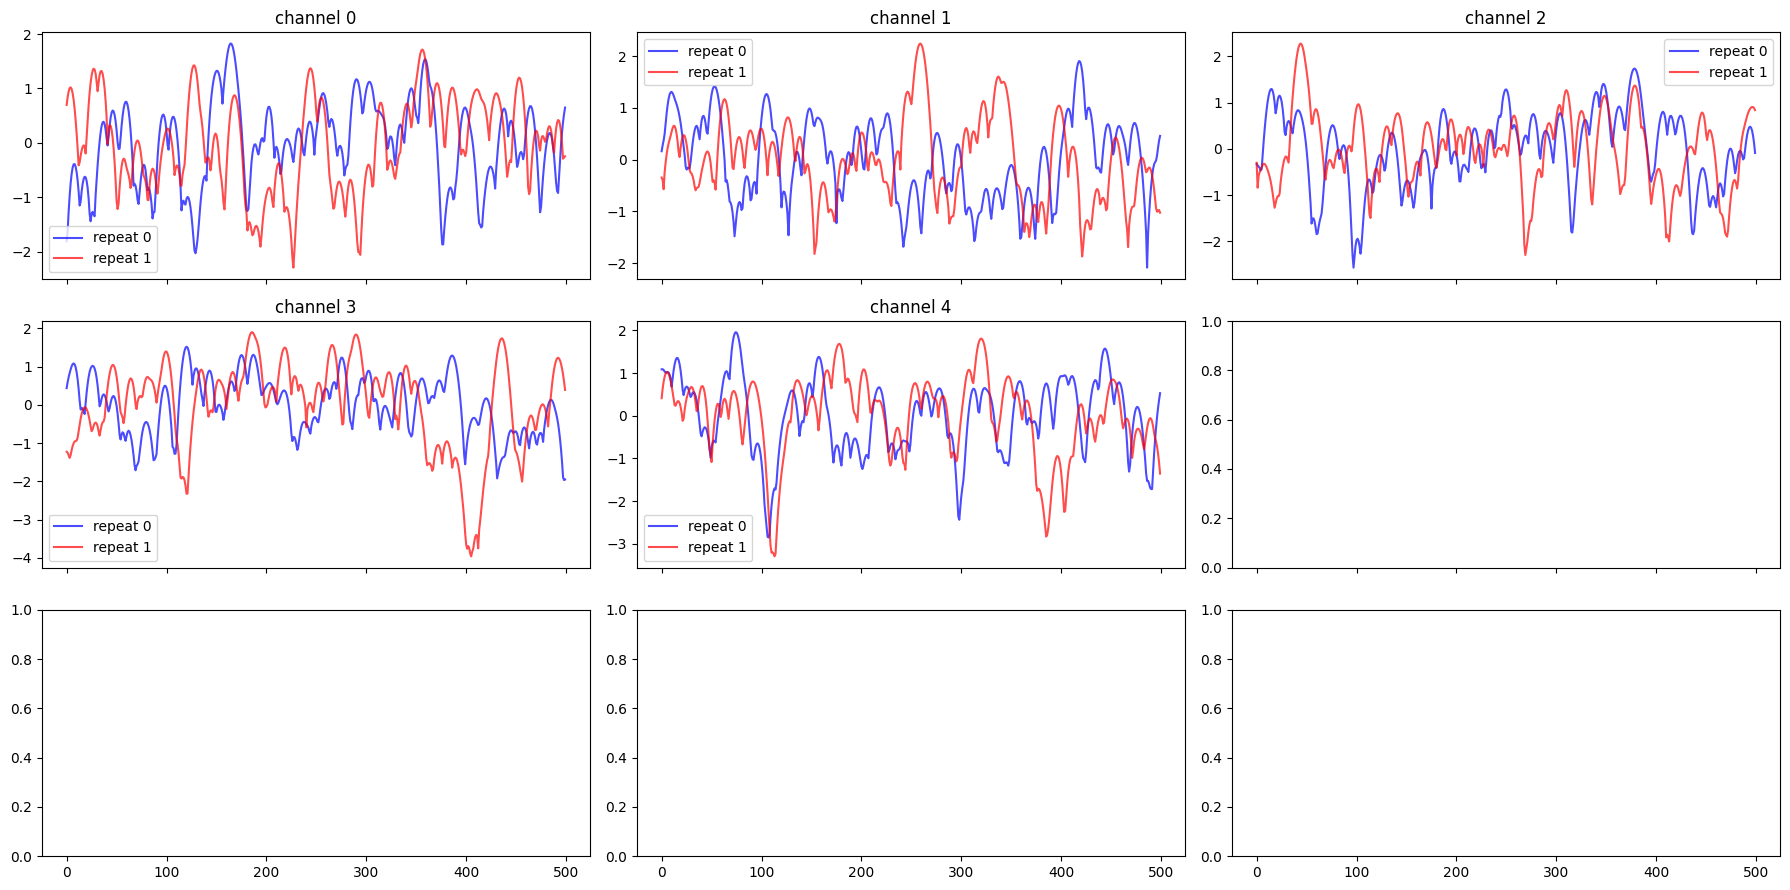

In [30]:
channels = list(range(0,len(data)))
repeats = [0,1]
colors = ['blue', 'red', 'green', 'orange']
nrows, ncols = 3, 3

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 3*nrows), sharex=True)

for ax, ch in zip(axes.flatten(), channels):
    centered = reduced_data[ch,0,:,:] - reduced_data[ch,0,:,:].mean(axis=0, keepdims=True)
    for rep, color in zip(repeats, colors):
        ax.plot(centered[:,rep], color=color, label=f'repeat {rep}', alpha=0.7)
    ax.set_title(f'channel {ch}')
    ax.legend()

plt.tight_layout()
plt.show()

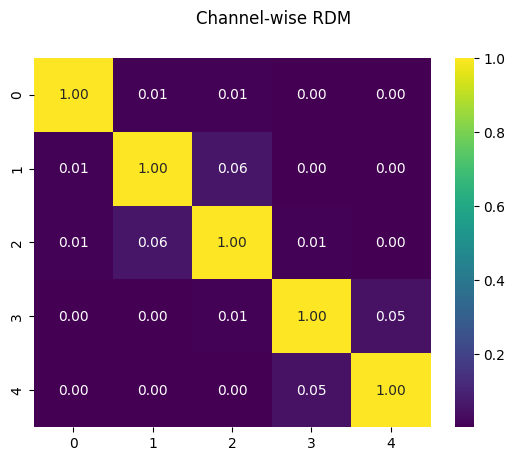

In [31]:
fig = sns.heatmap(rdm, annot=True, fmt=".2f", cmap='viridis').get_figure()
fig.suptitle('Channel-wise RDM')
plt.show()

0.9714388533511451 0.3254620041298283 1.654002548493891 0.15186948186983776


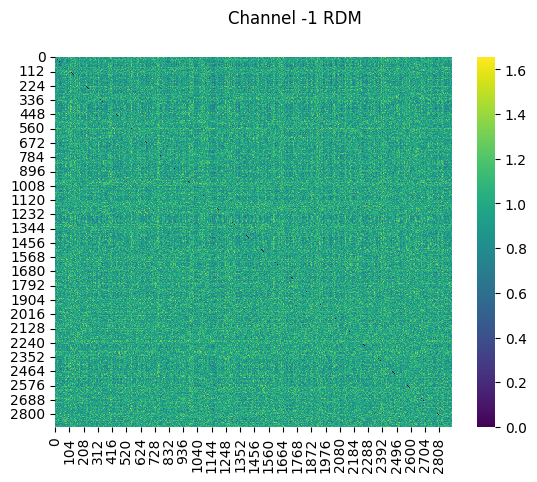

In [32]:
n=-1
print(rdms_channels[n].mean(), rdms_channels[n].min(), rdms_channels[n].max(), rdms_channels[n].std())
fig = sns.heatmap(squareform(rdms_channels[n]), cmap='viridis').get_figure()
fig.suptitle(f'Channel {n} RDM')
plt.show()

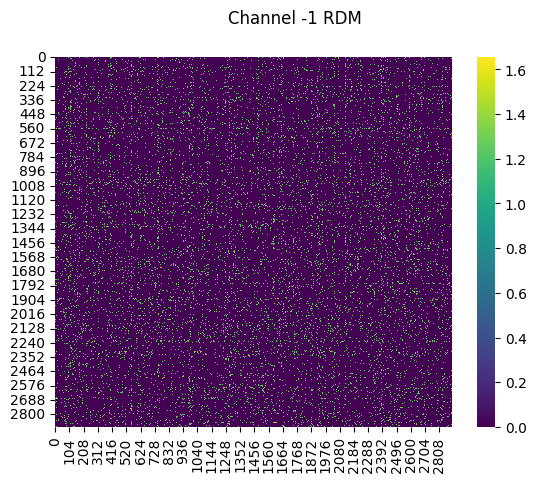

In [33]:
mask = rdms_channels[n] > 1.2
tmp = rdms_channels[n].copy()
tmp[~mask] = 0
fig = sns.heatmap(squareform(tmp), cmap='viridis').get_figure()
fig.suptitle(f'Channel {n} RDM')
plt.show()

<Axes: >

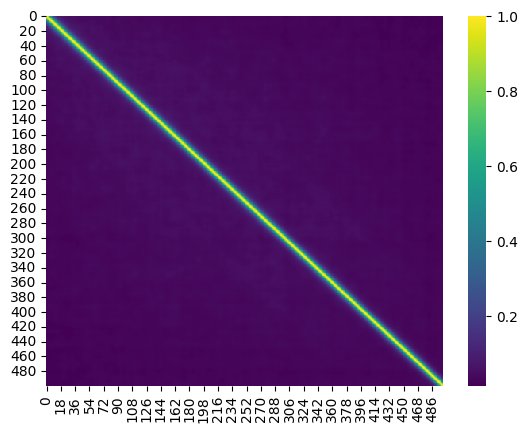

In [34]:
# Per-timepoint RDMs: how similar is the representational geometry at each t?
rdms_time = []
for t in range(data.shape[2]):  # 500 timepoints
    X = data[:, :, t].T  # (2900, 5) — conditions x channels
    rdm_t = squareform(pdist(X, metric='correlation'))
    rdms_time.append(rdm_t[np.triu_indices(2900, k=1)])

rdm_time = np.corrcoef(rdms_time)  # (500, 500)
sns.heatmap(rdm_time, cmap='viridis')

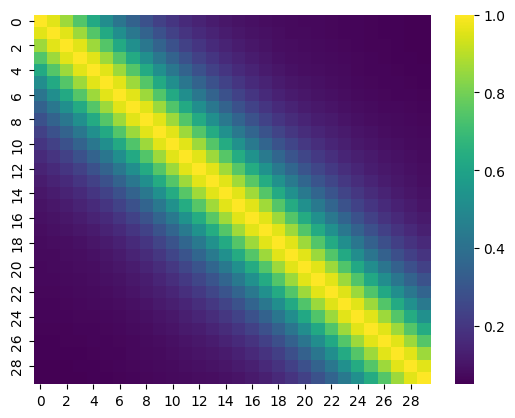

In [35]:
n=30
sns.heatmap(rdm_time[:n,:n], cmap='viridis')
plt.show()

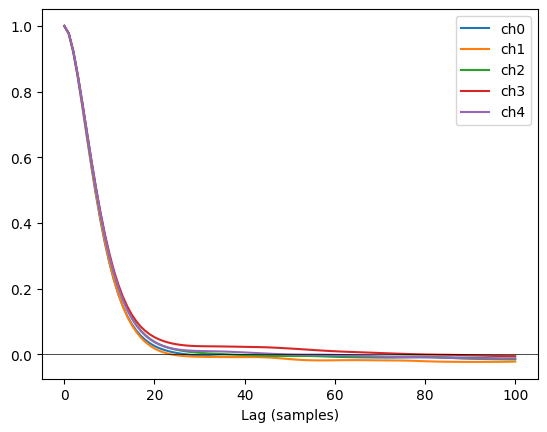

In [36]:
# Mean autocorrelation across conditions per channel
from statsmodels.tsa.stattools import acf

for ch in range(len(data)):
    # average acf across conditions
    ac = np.mean([acf(data[ch, cond, :], nlags=100, fft=True) 
                  for cond in range(2900)], axis=0)
    plt.plot(ac, label=f'ch{ch}')
plt.axhline(0, color='k', lw=0.5)
plt.xlabel('Lag (samples)'); plt.legend()
plt.show()

373 PCs explain 0.98 of the variance


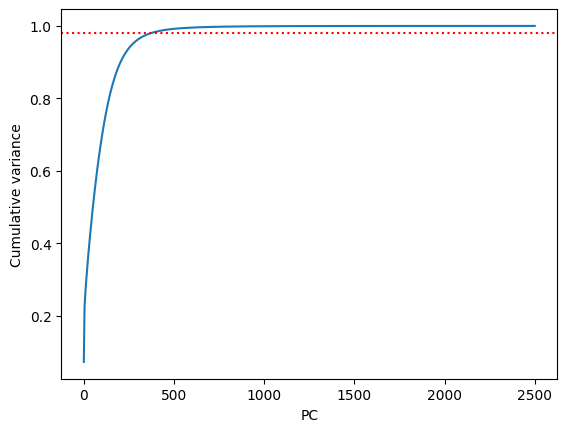

In [37]:
from sklearn.decomposition import PCA

# Flatten to (conditions, channels*time)
X = data.reshape(2900, -1)
pca = PCA().fit(X)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('PC'); plt.ylabel('Cumulative variance')

x = 0.98
plt.axhline(x, c='r', linestyle=':')
n_pcs = np.searchsorted(np.cumsum(pca.explained_variance_ratio_), x) + 1
print(f"{n_pcs} PCs explain {x} of the variance")

plt.show()

NCSNR results shape: (5, 500)
NC results shape: (5, 500)


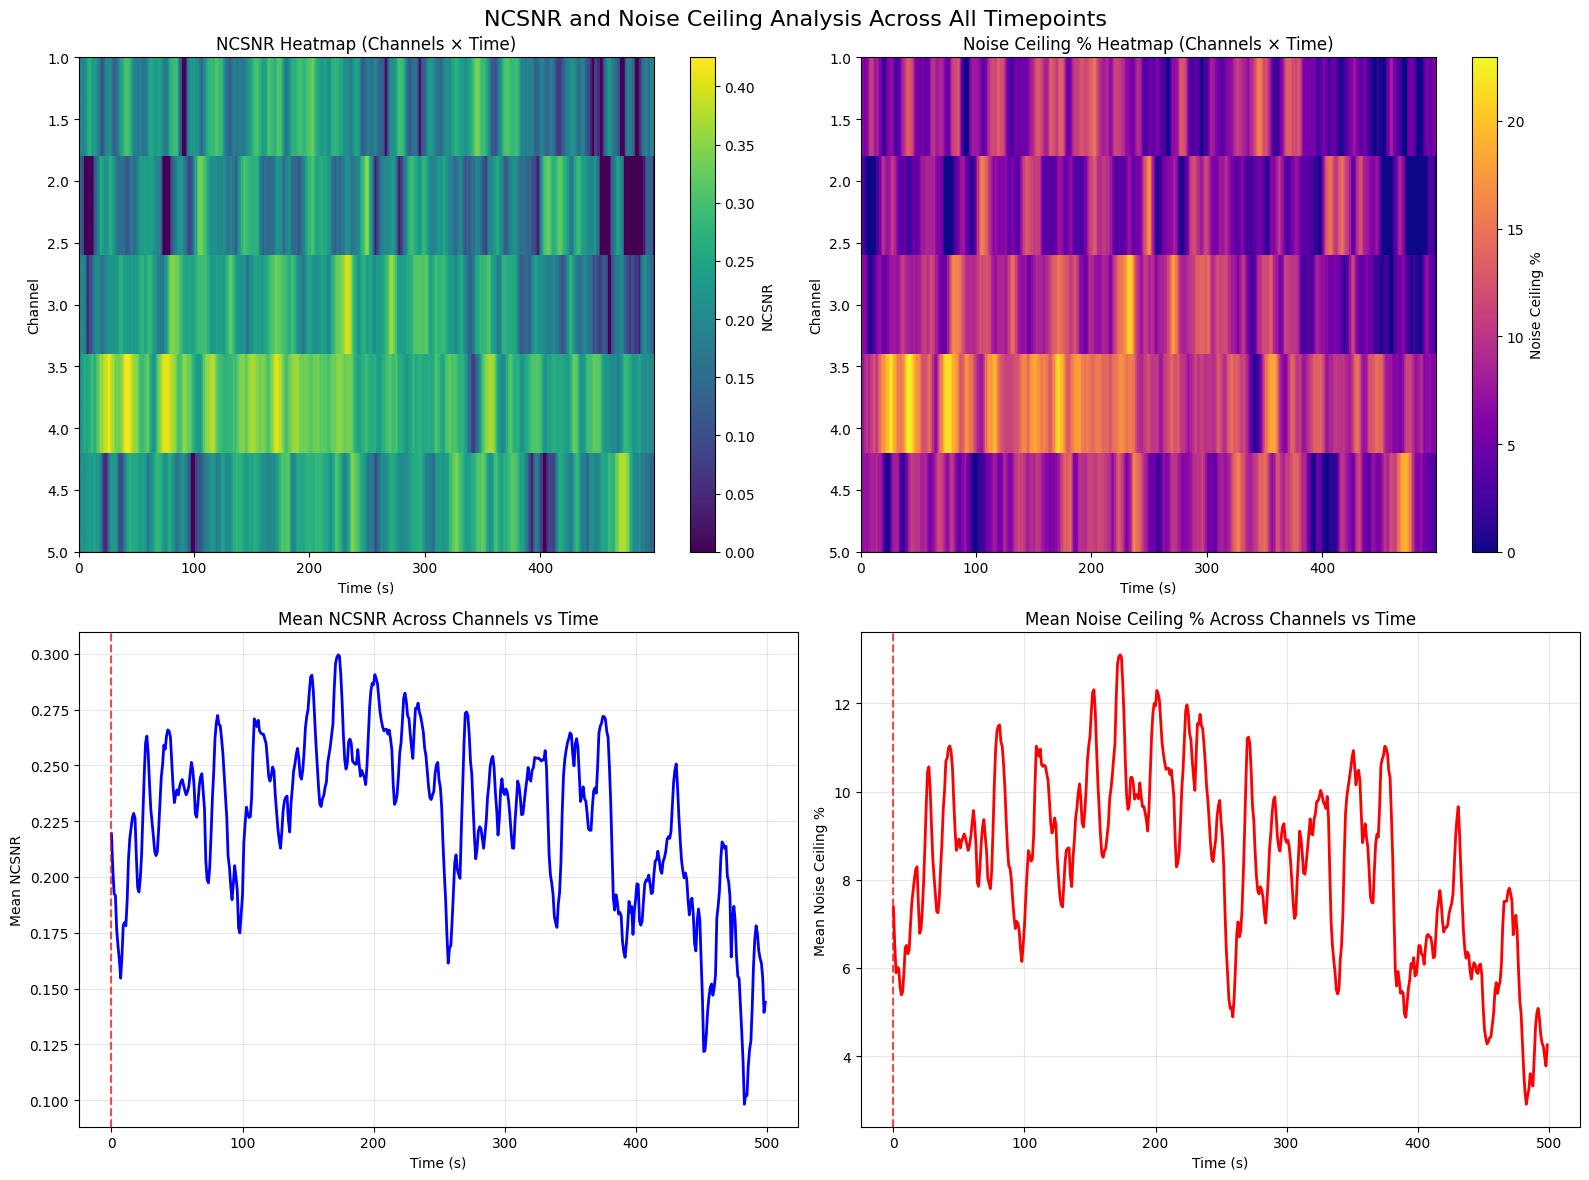


Summary Statistics:
Mean NCSNR across all channels and time: 0.226
Max NCSNR: 0.425
Mean Noise Ceiling across all channels and time: 8.4%
Max Noise Ceiling: 23.0%
Peak NCSNR time: 173.0ms
Peak NC time: 173.0ms


In [38]:
# plot NCSNR for the chosen electrodes and timepoints
ncsnr_all.shape
subsets = np.array([
    ncsnr_all[idx, center - window//2 : center + window//2]
    for idx, center in zip(high_ncsnr_idx, window_centers)
])
subsets_nc = np.array([
    nc_all[idx, center - window//2 : center + window//2]
    for idx, center in zip(high_ncsnr_idx, window_centers)
])
ncsnr_figs(subsets, subsets_nc, list(range(0,500)))